[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd5-drift/neurips-brain-body/05_inspect_latent_motion.ipynb)

# 05. Inspect fold-local latent motion without crossing roles

Load exactly one fold/seed/objective checkpoint, verify its hashes and tensor-access audit, then inspect train and validation representations. Test is a final, read-only lane after the diagnostics are fixed.

**Research use only.** Geometry in a synthetic smoke fixture is not scientific evidence.


In [1]:
from pathlib import Path
import copy
import hashlib
import json
import os
import random
import sys

import numpy as np
import pandas as pd
import torch
from IPython.display import SVG, display


def find_experiment_dir(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neurips-brain-body").is_dir() and (candidate / "data-gavd").is_dir():
            return candidate
        nested = candidate / "experiments" / "sjepa" / "gavd5-drift"
        if (nested / "neurips-brain-body").is_dir() and (nested / "data-gavd").is_dir():
            return nested
    raise FileNotFoundError("Could not locate experiments/sjepa/gavd5-drift")


EXPERIMENT_DIR = find_experiment_dir()
NOTEBOOK_DIR = EXPERIMENT_DIR / "neurips-brain-body"


# Use the same experiment-level configuration contract as notebooks 01-02.
# Existing process variables win, so CI and explicit shell overrides remain
# authoritative while an interactive Jupyter kernel still sees `.env`.
try:
    from dotenv import load_dotenv
    load_dotenv(EXPERIMENT_DIR / ".env", override=False)
except ImportError:
    pass
MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be 'smoke' or 'real'")

ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", EXPERIMENT_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
PROTOCOL_DIR = ARTIFACT_DIR / "evaluation_protocol"
POSE_DIR = ARTIFACT_DIR / "poses"
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
for folder in (ARTIFACT_DIR, CHECKPOINT_DIR):
    folder.mkdir(parents=True, exist_ok=True)


def truthy(name, default="0"):
    return os.getenv(name, default).strip().lower() in {"1", "true", "yes", "on"}


def show_tutorial_svg(filename):
    path = EXPERIMENT_DIR / "images" / filename
    if not path.is_file():
        raise FileNotFoundError(path)
    display(SVG(filename=str(path)))


OUTER_FOLD = int(os.getenv("SJEPA_OUTER_FOLD", "0"))
MODEL_SEED = int(os.getenv("SJEPA_MODEL_SEED", "42"))
if OUTER_FOLD not in range(5):
    raise ValueError("SJEPA_OUTER_FOLD must be one of 0, 1, 2, 3, 4")
random.seed(MODEL_SEED)
np.random.seed(MODEL_SEED)
torch.manual_seed(MODEL_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print({
    "mode": MODE,
    "outer_fold": OUTER_FOLD,
    "model_seed": MODEL_SEED,
    "device": str(DEVICE),
    "artifacts": str(ARTIFACT_DIR),
})


{'mode': 'real', 'outer_fold': 0, 'model_seed': 42, 'device': 'cpu', 'artifacts': 'C:\\Users\\alexm\\dev\\alexpose\\experiments\\sjepa\\gavd5-drift\\work\\artifacts\\real'}


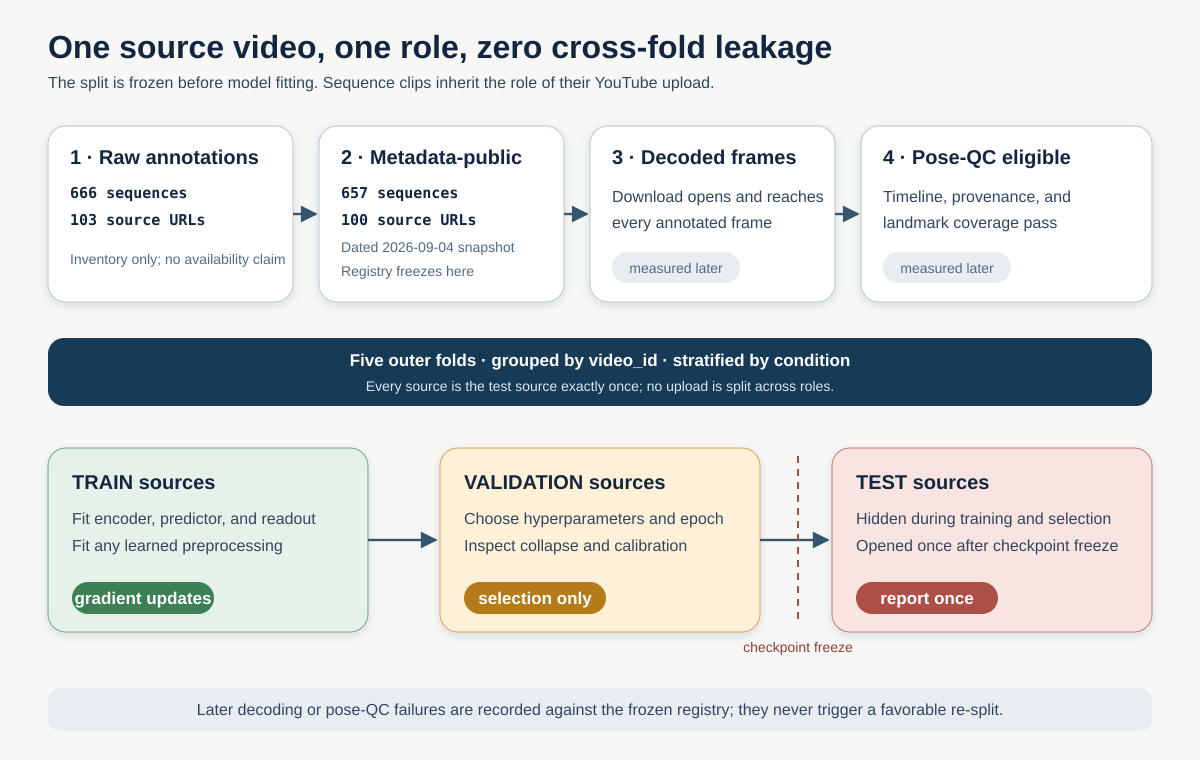

In [2]:
show_tutorial_svg("22_inductive_source_split.svg")


## Reference construction is part of the split

Centroids, feature scales, nearest-neighbor galleries, and any other reference statistics are fitted from **train sources only**. Validation is reported separately and may guide a documented modeling decision upstream. Outer test is not a second validation set; it is opened only in the final lane.

The fold-local notebook 02 pose-QC ledger is authoritative. Notebook 01's same-named value is only a pending placeholder; it is replaced after fold, manifest-hash, split-hash, and role validation. Pose locations use the explicit `pose_path` namespace so they cannot collide with downloaded-video `path` fields.


In [3]:
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
ROLE_ORDER = ["train", "validation", "test"]


def stable_seed(text):
    return int(hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:8], 16)


def table_sha256(table, columns):
    canonical = table.loc[:, columns].copy().sort_values(columns).reset_index(drop=True)
    payload = canonical.to_csv(index=False, lineterminator="\n").encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def synthetic_metadata(outer_fold=0):
    """Five sources per condition: three train, one validation, one test.

    These rows exercise provenance and isolation. They are not a disease model,
    benchmark sample, or substitute for GAVD.
    """
    rows = []
    test_slot = outer_fold % 5
    validation_slot = (outer_fold + 1) % 5
    for condition in CONDITIONS:
        for source_slot in range(5):
            role = (
                "test" if source_slot == test_slot
                else "validation" if source_slot == validation_slot
                else "train"
            )
            video_id = f"smoke_{condition}_source_{source_slot}"
            for sequence_slot in range(2):
                rows.append({
                    "condition": condition,
                    "video_id": video_id,
                    "sequence_id": f"{video_id}_sequence_{sequence_slot}",
                    "role": role,
                    "pose_qc_eligible": True,
                    "path": "",
                })
    table = pd.DataFrame(rows)
    manifest_sha = table_sha256(table, ["condition", "video_id", "sequence_id"])
    split_sha = table_sha256(table, ["condition", "video_id", "role"])
    return table, {
        "manifest_sha256": manifest_sha,
        "split_sha256": split_sha,
        "split_version": "smoke_source_fixture_v2",
    }


def load_protocol_metadata(outer_fold):
    """Load the frozen registry and fold-specific pose-QC gate.

    This function loads metadata only. Pose tensors are opened later and only for
    the role explicitly requested by the caller.
    """
    if str(NOTEBOOK_DIR) not in sys.path:
        sys.path.insert(0, str(NOTEBOOK_DIR))
    from evaluation_protocol import (
        attach_pose_qc_eligibility,
        expand_split,
        manifest_fingerprint,
        split_fingerprint,
        validate_split_registry,
    )

    manifest_path = PROTOCOL_DIR / "eligible_sequence_manifest.csv"
    registry_path = PROTOCOL_DIR / "source_split_registry.csv"
    contract_path = PROTOCOL_DIR / "source_split_contract.json"
    qc_path = PROTOCOL_DIR / f"pose_qc_eligibility_outer_fold_{outer_fold}.csv"
    for path in (manifest_path, registry_path, contract_path, qc_path):
        if not path.is_file():
            raise FileNotFoundError(
                f"Missing {path}. Real mode requires notebooks 01 and 02 for this fold."
            )

    manifest = pd.read_csv(manifest_path)
    registry = pd.read_csv(registry_path)
    contract = json.loads(contract_path.read_text(encoding="utf-8"))
    validate_split_registry(registry, manifest)
    manifest_sha = manifest_fingerprint(manifest)
    split_sha = split_fingerprint(registry)
    if manifest_sha != contract["manifest_sha256"]:
        raise ValueError("Frozen manifest hash differs from source_split_contract.json")
    if split_sha != contract["split_sha256"]:
        raise ValueError("Frozen registry hash differs from source_split_contract.json")

    split_rows = expand_split(manifest, registry, outer_fold)
    qc = pd.read_csv(qc_path)
    table = attach_pose_qc_eligibility(
        split_rows,
        qc,
        outer_fold=outer_fold,
        manifest_sha256=manifest_sha,
        split_sha256=split_sha,
    )
    table = table.loc[table["pose_qc_eligible"]].copy()
    if table.empty:
        raise RuntimeError("No pose-QC-eligible rows are available for this outer fold")
    return table, {
        "manifest_sha256": manifest_sha,
        "split_sha256": split_sha,
        "split_version": str(registry["split_version"].iloc[0]),
    }


def load_metadata(outer_fold):
    return synthetic_metadata(outer_fold) if MODE == "smoke" else load_protocol_metadata(outer_fold)


def synthetic_gait_sequence(condition, sequence_id, frames=36):
    """Deterministic code-path motion; not a physiological simulation."""
    rng = np.random.default_rng(stable_seed(sequence_id))
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    sequence = np.zeros((frames, 33, 4), dtype=np.float32)
    sequence[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28), 23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70), 27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92), 31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        sequence[:, joint, 0], sequence[:, joint, 1] = x, y
    amplitude, lift = 0.045, 0.025
    if condition == "parkinsons":
        amplitude, lift = amplitude * 0.55, lift * 0.55
    if condition == "myopathic":
        sequence[:, [11, 12], 0] += 0.025 * np.sin(phase)[:, None]
    for ankle, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and ankle == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            sequence[:, knee, 1] -= 0.04
        sequence[:, ankle, 0] += amplitude * wave
        sequence[:, knee, 0] += 0.4 * amplitude * wave
        sequence[:, foot, 0] += amplitude * wave
        sequence[:, ankle, 1] -= lift * np.maximum(wave, 0.0)
    sequence[..., :3] += rng.normal(0.0, 0.0025, sequence[..., :3].shape)
    missing = rng.random(sequence.shape[:2]) < 0.02
    sequence[missing, 3] = 0.0
    sequence[missing, :3] = np.nan
    return sequence


def load_pose_tensor(row, access_log):
    """Load one eligible pose and record the role-level tensor access."""
    role = str(row["role"])
    if MODE == "smoke":
        sequence = synthetic_gait_sequence(row["condition"], row["sequence_id"])
        path_label = f"synthetic://{row['sequence_id']}"
    else:
        candidate = Path(str(row.get("pose_path", "")))
        fallback = POSE_DIR / row["condition"] / f"{row['sequence_id']}.npz"
        path = candidate if candidate.is_file() else fallback
        if not path.is_file():
            raise FileNotFoundError(f"Pose-QC marked eligible but pose cache is missing: {path}")
        data = np.load(path, allow_pickle=False)
        required = {"sequence", "sequence_id", "video_id", "condition", "manifest_sha256", "split_sha256", "split_roles_json"}
        missing_keys = required.difference(data.files)
        if missing_keys:
            raise ValueError(f"Stale pose cache {path}; missing {sorted(missing_keys)}")
        expected = {
            "sequence_id": str(row["sequence_id"]),
            "video_id": str(row["video_id"]),
            "condition": str(row["condition"]),
            "manifest_sha256": MANIFEST_SHA256,
            "split_sha256": SPLIT_SHA256,
        }
        for key, value in expected.items():
            if str(data[key].item()) != value:
                raise ValueError(f"{path}: {key} does not match frozen protocol")
        role_map = json.loads(str(data["split_roles_json"].item()))
        if role_map.get(str(OUTER_FOLD)) != role:
            raise ValueError(f"{path}: role map does not match outer fold {OUTER_FOLD}")
        sequence = data["sequence"]
        path_label = str(path)
    access_log.append({
        "role": role,
        "video_id": str(row["video_id"]),
        "sequence_id": str(row["sequence_id"]),
        "path": path_label,
    })
    return sequence


In [4]:
import math
from torch import nn
from torch.nn import functional as F


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack([np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])], axis=1)
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(sequence, frames):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T,33,4], got {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    valid = (visibility >= 0.45) & np.isfinite(sequence[..., :3]).all(axis=-1)
    xyz = sequence[..., :3]
    hips = np.nanmean(xyz[:, [23, 24]], axis=1)
    fallback = np.nanmedian(hips, axis=0)
    fallback = np.nan_to_num(fallback, nan=0.0)
    hips = np.where(np.isfinite(hips), hips, fallback)
    xyz = xyz - hips[:, None, :]
    shoulder = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    scale = np.nanmedian(np.maximum(shoulder, hip))
    scale = float(scale) if np.isfinite(scale) and scale > 1e-6 else 1.0
    xyz = np.nan_to_num(xyz / scale, nan=0.0, posinf=0.0, neginf=0.0)
    xyz = temporal_resize(xyz, frames).astype(np.float32)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return xyz, valid


class SkeletonEncoder(nn.Module):
    def __init__(self, frames=32, segment_length=4, embed_dim=32, depth=1, heads=4):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames, self.segment_length = frames, segment_length
        self.segments, self.embed_dim = frames // segment_length, embed_dim
        self.patch = nn.Linear(3, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(33, embed_dim) * 0.02)
        self.mask_token = nn.Parameter(torch.zeros(embed_dim))
        layer = nn.TransformerEncoderLayer(
            embed_dim, heads, embed_dim * 2, dropout=0.0,
            activation="gelu", batch_first=True, norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch = len(x)
        return x.reshape(batch, self.segments, self.segment_length, 33, 3).mean(dim=2)

    def patch_valid(self, valid):
        batch = len(valid)
        return valid.reshape(batch, self.segments, self.segment_length, 33).all(dim=2)

    def forward(self, x, hidden=None):
        patches = self.patchify(x)
        tokens = self.patch(patches)
        if hidden is not None:
            tokens = torch.where(hidden[..., None], self.mask_token, tokens)
        tokens = tokens + self.time_pos[None, :, None, :] + self.joint_pos[None, None, :, :]
        shape = tokens.shape
        tokens = self.blocks(tokens.reshape(shape[0], shape[1] * shape[2], shape[3]))
        return self.norm(tokens).reshape(shape)


class SJEPAProjector(nn.Module):
    def __init__(self, embed_dim=32, project_dim=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(embed_dim, embed_dim), nn.GELU(), nn.Linear(embed_dim, project_dim))

    def forward(self, x):
        return self.net(x)


class SJEPAPredictor(nn.Module):
    def __init__(self, segments, embed_dim=32):
        super().__init__()
        self.position = nn.Parameter(torch.randn(segments, 33, embed_dim) * 0.02)
        self.net = nn.Sequential(nn.Linear(embed_dim, embed_dim * 2), nn.GELU(), nn.Linear(embed_dim * 2, embed_dim))

    def forward(self, context_tokens, visible):
        weight = visible[..., None].float()
        context = (context_tokens * weight).sum((1, 2)) / weight.sum((1, 2)).clamp_min(1.0)
        return self.net(context[:, None, None, :] + self.position[None])


def model_components(config, device=DEVICE):
    online = SkeletonEncoder(**config).to(device)
    target = copy.deepcopy(online).to(device).eval()
    for parameter in target.parameters():
        parameter.requires_grad_(False)
    predictor = SJEPAPredictor(online.segments, config["embed_dim"]).to(device)
    projector = SJEPAProjector(config["embed_dim"], config["embed_dim"]).to(device)
    group_head = nn.Linear(config["embed_dim"], len(CONDITIONS)).to(device)
    return online, target, predictor, projector, group_head


def uniform_target_mask(valid_patch, fraction, generator):
    eligible_joint = torch.zeros(33, dtype=torch.bool, device=valid_patch.device)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.flatten(1).sum(1)
    if int(counts.min()) < 2:
        raise ValueError("Every pose-QC sample needs at least two eligible target tokens")
    count = max(1, min(int(counts.min()) - 1, int(math.floor(int(counts.min()) * fraction))))
    mask = torch.zeros_like(eligible)
    for index in range(len(mask)):
        candidates = torch.nonzero(eligible[index].flatten(), as_tuple=False).flatten().cpu().numpy()
        chosen = generator.choice(candidates, size=count, replace=False)
        mask[index].view(-1)[torch.as_tensor(chosen, device=mask.device)] = True
    return mask


def masked_pool(tokens, valid):
    weight = valid[..., None].float()
    return (tokens * weight).sum((1, 2)) / weight.sum((1, 2)).clamp_min(1.0)


def vicreg_terms(projected):
    if len(projected) < 2:
        zero = projected.sum() * 0.0
        return zero, zero
    centered = projected - projected.mean(0)
    std = torch.sqrt(projected.var(0, unbiased=False) + 1e-4)
    variance = F.relu(1.0 - std).mean()
    covariance = centered.T @ centered / max(len(projected) - 1, 1)
    covariance = covariance - torch.diag(torch.diag(covariance))
    return variance, covariance.square().sum() / projected.shape[1]


def weighted_stats(tokens, valid):
    weight = valid[..., None].float()
    denom = weight.sum((1, 2)).clamp_min(1.0)
    mean = (tokens * weight).sum((1, 2)) / denom
    var = ((tokens - mean[:, None, None]) ** 2 * weight).sum((1, 2)) / denom
    return mean, torch.sqrt(var + 1e-6)


@torch.no_grad()
def embed_prepared(target_encoder, prepared, batch_size=32):
    target_encoder.eval()
    chunks = []
    for start in range(0, len(prepared), batch_size):
        batch = prepared[start:start + batch_size]
        xyz = torch.as_tensor(np.stack([r["xyz"] for r in batch]), device=DEVICE)
        valid = torch.as_tensor(np.stack([r["valid"] for r in batch]), device=DEVICE)
        tokens = target_encoder(xyz)
        patch_valid = target_encoder.patch_valid(valid)
        overall = weighted_stats(tokens, patch_valid)
        neuro = weighted_stats(tokens[:, :, MASK_KEYPOINTS], patch_valid[:, :, MASK_KEYPOINTS])
        chunks.append(torch.cat([*overall, *neuro], dim=1).cpu().numpy())
    return np.concatenate(chunks, axis=0)


## How to read the progress display

Four stages verify checkpoint lineage, materialize train/validation embeddings,
compute development diagnostics, and finally open the outer-test role once and
write its audit. A failed stage leaves the active contract visible. Completion
means the workflow ran, not that any diagnostic supports a biological claim.


In [5]:
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from notebook_progress import NotebookTaskProgress

latent_progress = NotebookTaskProgress(
    'Latent-motion audit progress',
    "stage",
    refresh_seconds=0.5,
)
latent_progress.start(4, profile=MODE)

with latent_progress.unit(1, "Verify checkpoint lineage and freeze the encoder"):
    GROUP_ABLATION = truthy("SJEPA_ENABLE_GROUP_LOSS", "0")
    OBJECTIVE_NAME = "jepa_vicreg_group_ablation" if GROUP_ABLATION else "jepa_vicreg"
    CHECKPOINT_PATH = CHECKPOINT_DIR / f"sjepa_outer_fold_{OUTER_FOLD}_seed_{MODEL_SEED}_{OBJECTIVE_NAME}.pt"
    SIDECAR_PATH = CHECKPOINT_PATH.with_suffix(".json")
    for path in (CHECKPOINT_PATH, SIDECAR_PATH):
        if not path.is_file():
            raise FileNotFoundError(f"Missing {path}. Run notebook 04 with matching fold, seed, and objective.")

    sidecar = json.loads(SIDECAR_PATH.read_text(encoding="utf-8"))
    if file_sha256(CHECKPOINT_PATH) != sidecar["checkpoint_sha256"]:
        raise ValueError("Checkpoint bytes do not match the JSON sidecar")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    required_contract_keys = {
        "contract_version", "outer_fold", "model_seed", "objective",
        "manifest_sha256", "split_sha256", "split_version", "role_video_ids",
        "role_sequence_ids", "encoder_fit_video_ids", "checkpoint_selection_video_ids",
        "test_tensors_loaded", "tensor_access_log", "model_config", "model_state",
    }
    missing_contract = required_contract_keys.difference(checkpoint)
    if missing_contract:
        raise ValueError(f"Checkpoint lacks contract fields: {sorted(missing_contract)}")
    if checkpoint["contract_version"] != "sjepa_fold_contract_v2":
        raise ValueError("Unsupported checkpoint contract")
    if checkpoint["outer_fold"] != OUTER_FOLD or checkpoint["model_seed"] != MODEL_SEED:
        raise ValueError("Checkpoint fold/seed mismatch")
    if checkpoint["objective"]["name"] != OBJECTIVE_NAME:
        raise ValueError("Checkpoint objective mismatch")
    if checkpoint["test_tensors_loaded"] is not False:
        raise ValueError("Training checkpoint reports test tensor access")

    metadata, protocol = load_metadata(OUTER_FOLD)
    MANIFEST_SHA256 = protocol["manifest_sha256"]
    SPLIT_SHA256 = protocol["split_sha256"]
    for key, expected in [("manifest_sha256", MANIFEST_SHA256), ("split_sha256", SPLIT_SHA256)]:
        if checkpoint[key] != expected or sidecar[key] != expected:
            raise ValueError(f"{key} mismatch between data, checkpoint, and sidecar")

    role_video_ids = {
        role: sorted(metadata.loc[metadata["role"].eq(role), "video_id"].astype(str).unique())
        for role in ROLE_ORDER
    }
    if role_video_ids != checkpoint["role_video_ids"]:
        raise ValueError("Current pose-QC role IDs differ from checkpoint contract")
    if set(checkpoint["encoder_fit_video_ids"]) & set(role_video_ids["test"]):
        raise ValueError("Encoder fit sources overlap outer-test sources")

    online_encoder, target_encoder, predictor, projector, group_head = model_components(checkpoint["model_config"])
    online_encoder.load_state_dict(checkpoint["model_state"]["online_encoder"])
    target_encoder.load_state_dict(checkpoint["model_state"]["target_encoder"])
    predictor.load_state_dict(checkpoint["model_state"]["predictor"])
    projector.load_state_dict(checkpoint["model_state"]["projector"])
    if "group_head" in checkpoint["model_state"]:
        group_head.load_state_dict(checkpoint["model_state"]["group_head"])
    for module in (online_encoder, target_encoder, predictor, projector, group_head):
        module.eval()
        for parameter in module.parameters():
            parameter.requires_grad_(False)

    print({
        "checkpoint": CHECKPOINT_PATH.name,
        "checkpoint_sha256": sidecar["checkpoint_sha256"],
        "manifest_sha256": MANIFEST_SHA256,
        "split_sha256": SPLIT_SHA256,
        "test_tensors_loaded_during_training": checkpoint["test_tensors_loaded"],
    })


{'checkpoint': 'sjepa_outer_fold_0_seed_42_jepa_vicreg.pt', 'checkpoint_sha256': 'f510be2a0453dda0d6698780fcd998835db213e39d94e345b227a5ed8ec648ac', 'manifest_sha256': '7fd559e5105b11011a3e5c194b7ccc29729c56491c424745834df39884123b5a', 'split_sha256': 'ff3518b87b1d1fa7d95efb1aea1711773137a21699967cb8015edb8d845ccbe1', 'test_tensors_loaded_during_training': False}


C:\Users\alexm\AppData\Local\Temp\ipykernel_23500\694196087.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, depth)


In [6]:
with latent_progress.unit(2, "Materialize train and validation embeddings"):
    tensor_access_log = []


    def materialize_role(role):
        rows = metadata.loc[metadata["role"].eq(role)].sort_values("sequence_id")
        records = []
        for _, row in rows.iterrows():
            xyz, valid = prepare_sequence(load_pose_tensor(row, tensor_access_log), checkpoint["model_config"]["frames"])
            records.append({**row.to_dict(), "xyz": xyz, "valid": valid})
        return records


    def embedding_frame(records):
        matrix = embed_prepared(target_encoder, records)
        frame = pd.DataFrame(matrix, columns=[f"z_{index:03d}" for index in range(matrix.shape[1])])
        for column in ["sequence_id", "video_id", "condition", "role"]:
            frame[column] = [record[column] for record in records]
        return frame


    train_records = materialize_role("train")
    validation_records = materialize_role("validation")
    assert not ({row["video_id"] for row in tensor_access_log} & set(role_video_ids["test"]))
    train_embeddings = embedding_frame(train_records)
    validation_embeddings = embedding_frame(validation_records)
    feature_columns = [column for column in train_embeddings if column.startswith("z_")]
    print({
        "train_sequences": len(train_embeddings),
        "validation_sequences": len(validation_embeddings),
        "test_tensors_loaded": False,
    })


C:\Users\alexm\AppData\Local\Temp\ipykernel_23500\694196087.py:24: RuntimeWarning: Mean of empty slice
  hips = np.nanmean(xyz[:, [23, 24]], axis=1)
C:\Users\alexm\AppData\Local\Temp\ipykernel_23500\694196087.py:24: RuntimeWarning: Mean of empty slice
  hips = np.nanmean(xyz[:, [23, 24]], axis=1)


{'train_sequences': 377, 'validation_sequences': 131, 'test_tensors_loaded': False}


## Train reference, validation diagnostics

The normal reference below is the mean of **source-aggregated train embeddings**. Source aggregation prevents a video with many excerpts from becoming a heavier reference. Nearest-neighbor retrieval explicitly removes the query's source video even when roles are already disjoint.


In [7]:
with latent_progress.unit(3, "Compute development-only geometry diagnostics"):
    from sklearn.metrics import pairwise_distances, silhouette_score
    from sklearn.metrics.pairwise import cosine_similarity


    def aggregate_sources(frame):
        features = frame.groupby(["role", "video_id", "condition"], as_index=False)[feature_columns].mean()
        return features


    train_sources = aggregate_sources(train_embeddings)
    validation_sources = aggregate_sources(validation_embeddings)
    normal_reference = train_sources.loc[
        train_sources["condition"].eq("normal"), feature_columns
    ].to_numpy().mean(axis=0)
    train_scale = train_sources[feature_columns].to_numpy().std(axis=0) + 1e-6


    def role_diagnostics(frame, role):
        sources = aggregate_sources(frame)
        matrix = sources[feature_columns].to_numpy()
        distance = np.linalg.norm((matrix - normal_reference) / train_scale, axis=1)
        silhouette = float("nan")
        if sources["condition"].nunique() > 1 and len(sources) > sources["condition"].nunique():
            silhouette = float(silhouette_score(matrix, sources["condition"]))
        return {
            "role": role,
            "sources": int(len(sources)),
            "mean_train_normal_distance": float(distance.mean()),
            "condition_silhouette": silhouette,
        }


    def nearest_train_neighbor(query_row):
        candidates = train_sources.loc[train_sources["video_id"].ne(query_row["video_id"])].copy()
        if candidates.empty:
            raise RuntimeError("No different-source training neighbor is available")
        similarity = cosine_similarity(
            query_row[feature_columns].to_numpy(dtype=float)[None],
            candidates[feature_columns].to_numpy(dtype=float),
        )[0]
        best = int(np.argmax(similarity))
        return {
            "query_video": query_row["video_id"],
            "query_condition": query_row["condition"],
            "neighbor_video": candidates.iloc[best]["video_id"],
            "neighbor_condition": candidates.iloc[best]["condition"],
            "cosine_similarity": float(similarity[best]),
            "same_video": False,
        }


    diagnostic_rows = [
        role_diagnostics(train_embeddings, "train"),
        role_diagnostics(validation_embeddings, "validation"),
    ]
    validation_retrieval = nearest_train_neighbor(validation_sources.iloc[0])
    display(pd.DataFrame(diagnostic_rows))
    display(pd.DataFrame([validation_retrieval]))


,role,sources,mean_train_normal_distance,condition_silhouette
0,train,59,15.383401,-0.108600
1,validation,18,19.494282,-0.264261


,query_video,query_condition,neighbor_video,neighbor_condition,cosine_similarity,same_video
0,-MQBffDuto4,cerebralpalsy,A2-NkglbQu0,myopathic,0.988058,False


## Final outer-test lane

Everything above—including checkpoint choice, train reference, scale, pooling, and retrieval rule—is now fixed. The following cell opens test pose tensors once. It reports test separately and never folds test statistics back into a reference or hyperparameter.


In [8]:
with latent_progress.unit(4, "Open test sources once and persist the latent audit"):
    test_records = materialize_role("test")
    test_embeddings = embedding_frame(test_records)
    test_sources = aggregate_sources(test_embeddings)
    test_diagnostics = role_diagnostics(test_embeddings, "test_final")
    test_retrieval = nearest_train_neighbor(test_sources.iloc[0])
    assert test_retrieval["same_video"] is False
    display(pd.DataFrame([test_diagnostics]))
    display(pd.DataFrame([test_retrieval]))

    latent_audit = {
        "contract_version": "sjepa_latent_audit_v2",
        "outer_fold": OUTER_FOLD,
        "model_seed": MODEL_SEED,
        "objective": OBJECTIVE_NAME,
        "manifest_sha256": MANIFEST_SHA256,
        "split_sha256": SPLIT_SHA256,
        "checkpoint_sha256": sidecar["checkpoint_sha256"],
        "diagnostics": diagnostic_rows + [test_diagnostics],
        "nearest_neighbor_rule": "train gallery only; same video excluded",
        "validation_retrieval": validation_retrieval,
        "test_retrieval": test_retrieval,
    }
    output_path = ARTIFACT_DIR / f"latent_audit_outer_fold_{OUTER_FOLD}_seed_{MODEL_SEED}_{OBJECTIVE_NAME}.json"
    output_path.write_text(json.dumps(latent_audit, indent=2) + "\n", encoding="utf-8")
    print("saved", output_path)
latent_progress.complete(status="Latent-motion audit complete")


C:\Users\alexm\AppData\Local\Temp\ipykernel_23500\694196087.py:24: RuntimeWarning: Mean of empty slice
  hips = np.nanmean(xyz[:, [23, 24]], axis=1)


,role,sources,mean_train_normal_distance,condition_silhouette
0,test_final,20,16.719585,-0.193533


,query_video,query_condition,neighbor_video,neighbor_condition,cosine_similarity,same_video
0,-0wbleNgAwg,normal,mBAxLr73IHU,normal,0.982134,False


saved C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real\latent_audit_outer_fold_0_seed_42_jepa_vicreg.json


## What these diagnostics can support

They can reveal collapse, unstable validation geometry, or source-specific retrieval. They cannot establish diagnostic validity, subject independence, or causal disease structure. Report train, validation, and final test lanes separately; aggregate outer-test results only after all folds and seeds are complete.


## Visual representation diagnostics

Distances are measured from the train-normal reference; silhouettes summarize separation by dataset folder label. These are geometry diagnostics rather than clinical endpoints, and negative silhouette values are retained rather than cosmetically clipped.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


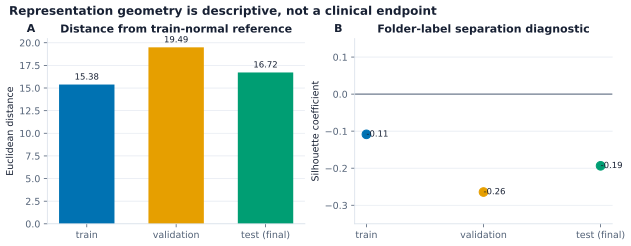

Notebook SVG: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real\figures\bbfm_latent_geometry.svg
Paper assets: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_latent_geometry.svg C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_latent_geometry.png C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_latent_geometry.pdf


In [1]:
# Paper and notebook rendering share this single source of truth.
from pathlib import Path as _VisualPath
import os as _visual_os
import sys as _visual_sys


def _find_visual_experiment(start=None):
    start = _VisualPath(start or _VisualPath.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neurips-brain-body").is_dir() and (candidate / "data-gavd").is_dir():
            return candidate
        nested = candidate / "experiments" / "sjepa" / "gavd5-drift"
        if (nested / "neurips-brain-body").is_dir() and (nested / "data-gavd").is_dir():
            return nested
    raise FileNotFoundError("Could not locate experiments/sjepa/gavd5-drift")


_visual_experiment = _VisualPath(globals().get("EXPERIMENT_DIR", _find_visual_experiment())).resolve()
_visual_notebook_dir = _visual_experiment / "neurips-brain-body"
if str(_visual_notebook_dir) not in _visual_sys.path:
    _visual_sys.path.insert(0, str(_visual_notebook_dir))
try:
    from dotenv import load_dotenv as _visual_load_dotenv
    _visual_load_dotenv(_visual_experiment / ".env", override=False)
except ImportError:
    pass
_visual_mode = str(globals().get("MODE", _visual_os.getenv("GAVD_MODE", "real"))).strip().lower()
_visual_artifact_root = _VisualPath(
    _visual_os.getenv("GAVD_ARTIFACT_DIR", _visual_experiment / "work" / "artifacts")
).expanduser()
_visual_artifact_dir = _VisualPath(globals().get("ARTIFACT_DIR", _visual_artifact_root / _visual_mode))
_visual_outer_fold = int(globals().get("OUTER_FOLD", _visual_os.getenv("SJEPA_OUTER_FOLD", "0")))
_visual_seed = int(globals().get("MODEL_SEED", _visual_os.getenv("SJEPA_MODEL_SEED", "42")))
_visual_objective = str(globals().get("OBJECTIVE_NAME", _visual_os.getenv("SJEPA_OBJECTIVE", "jepa_vicreg")))

from scientific_visuals import render_notebook_summary

visual_summary = render_notebook_summary(
    "05",
    experiment_dir=_visual_experiment,
    artifact_dir=_visual_artifact_dir,
    outer_fold=_visual_outer_fold,
    model_seed=_visual_seed,
    objective=_visual_objective,
)
print("Notebook SVG:", visual_summary.notebook_svg)
print("Paper assets:", visual_summary.paper_svg, visual_summary.paper_png, visual_summary.paper_pdf)
